In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from word2number import w2n

In [102]:
df = pd.read_csv('hiring.csv')
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [103]:
w2n.word_to_num('point one')

0.1

In [104]:
df['test_score(out of 10)'].median()

8.0

In [105]:
df.experience.fillna('Zero', inplace=True)
df['test_score(out of 10)'].fillna(df['test_score(out of 10)'].median(), inplace=True)
df

/tmp/ipython-input-254063948.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.experience.fillna('Zero', inplace=True)
/tmp/ipython-input-254063948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,Zero,8.0,9,50000
1,Zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [106]:
df['experience'] = df.experience.apply(lambda x: w2n.word_to_num(x))

In [107]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


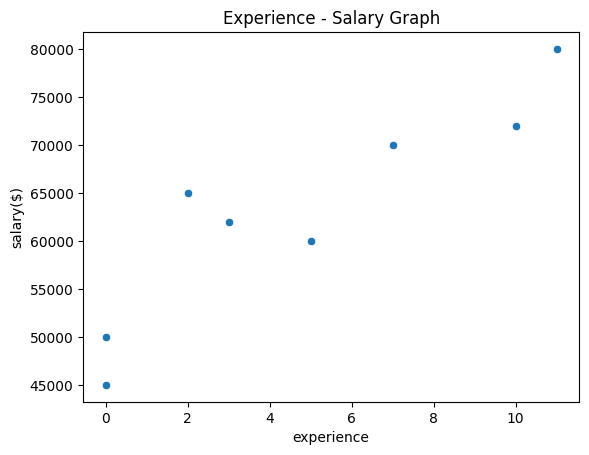

In [108]:
sns.scatterplot(data=df, x='experience', y='salary($)')
plt.title('Experience - Salary Graph')
plt.show()

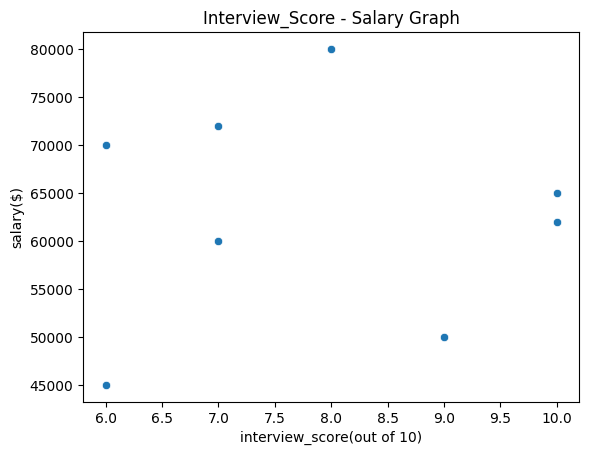

In [109]:
sns.scatterplot(data=df, x='interview_score(out of 10)', y='salary($)')
plt.title('Interview_Score - Salary Graph')
plt.show()

In [110]:
model = linear_model.LinearRegression().fit(df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']], df['salary($)'])

In [111]:
model.predict([[2,9,6]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53205.96797671])

In [112]:
model.predict([[12, 10, 10]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92002.18340611])

In [113]:
model.predict([[5, 6, 7]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([58312.95487627])

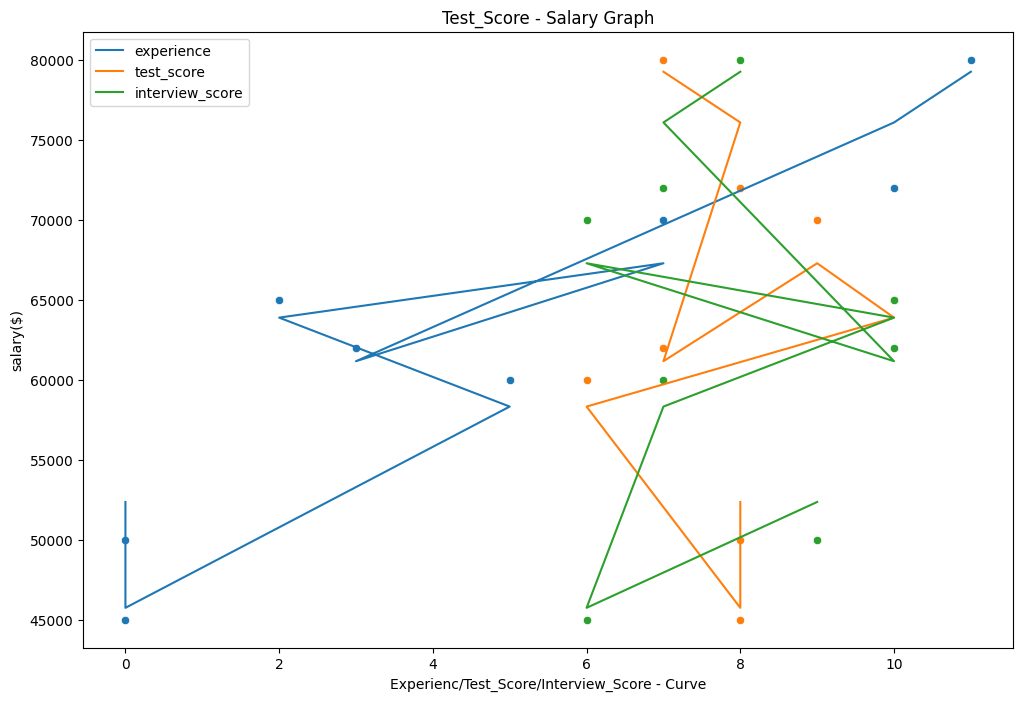

In [114]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='experience', y='salary($)')
sns.scatterplot(data=df, x='test_score(out of 10)', y='salary($)')
sns.scatterplot(data=df, x='interview_score(out of 10)', y='salary($)')
plt.plot(df['experience'], model.predict(df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]), label='experience')
plt.plot(df['test_score(out of 10)'], model.predict(df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]), label='test_score')
plt.plot(df['interview_score(out of 10)'], model.predict(df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']]), label='interview_score')
plt.legend()
plt.xlabel('Experienc/Test_Score/Interview_Score - Curve')
plt.title('Test_Score - Salary Graph')
plt.show()